In [15]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import norm, rankdata
from scipy.optimize import minimize, brentq
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

from sklearn.preprocessing import PowerTransformer
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import torch
import torch.nn as nn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    return '-'.join([f'{x:.{decimals}f}' for x in point])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 11

Function 1 - Week 11
Largest gap: -19.6 to -39.6
Floor set at: -29.6
Strongest detection: 1.346625e+00 at [0.624182 0.616547]
  log reading: 0.1
Log reading range: -29.6 to 0.1

All points (sorted by detection strength):
  [0.624182 0.616547] --> output: 1.347e+00 --> log reading: 0.1
  [0.647707 0.639762] --> output: 5.894e-01 --> log reading: -0.2
  [0.603501 0.653629] --> output: 7.759e-02 --> log reading: -1.1
  [0.65011406 0.68152635] --> output: -3.606e-03 --> log reading: -2.4
  [0.694651 0.629916] --> output: -1.607e-03 --> log reading: -2.8
  [0.461537 0.459084] --> output: -1.688e-05 --> log reading: -4.8
  [0.504751 0.602966] --> output: 1.949e-12 --> log reading: -11.7
  [0.73102363 0.73299988] --> output: 7.711e-16 --> log reading: -15.1
  [0.618043 0.460066] --> output: 2.603e-20 --> log reading: -19.6
  [0.31269116 0.07872278] --> output: -2.089e-91 --> log reading: -29.6
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> log reading: -29.6
  [0.84035342 0.26473161] -->

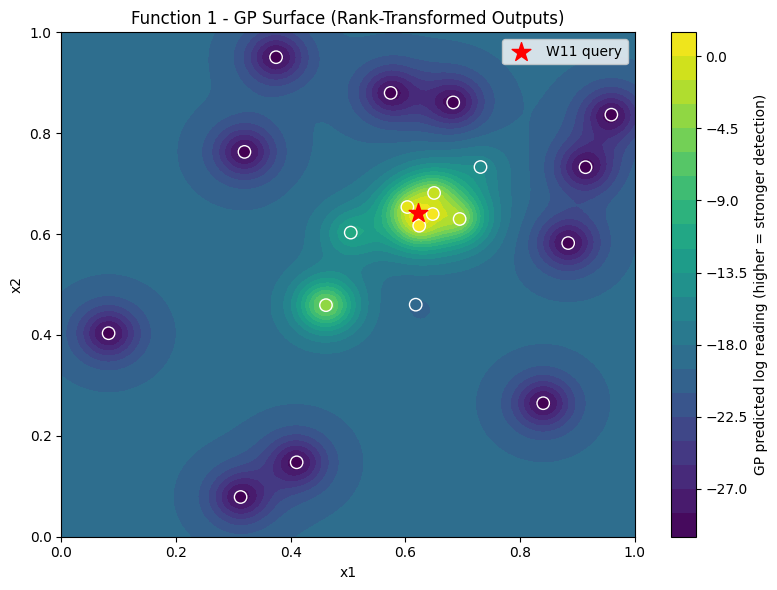

In [17]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes: 
#    - added week 10 source points to the distance calculation for the length scale
#    - removed 1.5 muliplier for the length scale, since it was overshooting the peak 
#      (now I have enough resolution within this region without the mulitplier)
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 11")
print("=" * 60)
 
inputs  = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],
    [0.504751, 0.602966],
    [0.624182, 0.616547], # W8:  1.3466
    [0.603501, 0.653629], # W9:  0.0775
    [0.647707, 0.639762], # W10: 0.5893
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
    1.9491751435286236e-12,
    1.3466251251333927,
    0.07758657745022698,
    0.5893718994659691,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])
 
# log-abs transform: measures detection strength on a log scale
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the natural gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
ceiling = np.max(np.log10(np.abs(all_outputs) + 1e-300))
log_readings = np.clip(log_readings, floor, ceiling)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")
 
# print all points for verification
print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> log reading: {log_readings[i]:.1f}")

# source-1 points used to to generate the ls estimate
source1_points = np.array([
    [0.624182, 0.616547],  # W8: 1.347 confirmed signal
    [0.603501, 0.653629],  # W9: 0.078
    [0.647707, 0.639762],  # W10: 0.5893 
])

pairs = [(0,1),(0,2),(1,2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i,j in pairs]
ls = np.mean(dists)
print(f"Length scale: {ls:.3f}")

# GP
kernel = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, log_readings)

# EI over candidates
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))

mu, sigma = gp.predict(candidates, return_std=True)

# Expected Improvement
best_so_far = log_readings.max()
ei = compute_ei(mu, sigma, best_so_far, xi=0.5)

best_idx = np.argmax(ei)
query = candidates[best_idx]

print(f"\nWeek 11 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}, EI: {ei[best_idx]:.4f}")
 
# --- Interpretability: 2D heatmap of GP predicted surface ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W11 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2 - week 11


Function 2 - Week 11
Total points: 20
Current best: 0.685

Output transformation (Yeo-Johnson):
  W8 original: 0.6848 → transformed: 1.3924

Feature importances: x1=0.957, x2=0.043

Learned kernel: Matern(length_scale=[0.0507, 0.1], nu=2.5) + WhiteKernel(noise_level=0.0145)
  Noise level: 0.0145, sigma: 0.1205

Sanity check at W8:
  GP predicted (original space): 0.6802  (actual: 0.6848)

Week 11 Query: 0.688548-0.445022
  GP mean (original space): 0.6673
  GP std (transformed):     0.3787
  UCB score:                1.5104  (kappa=0.5)


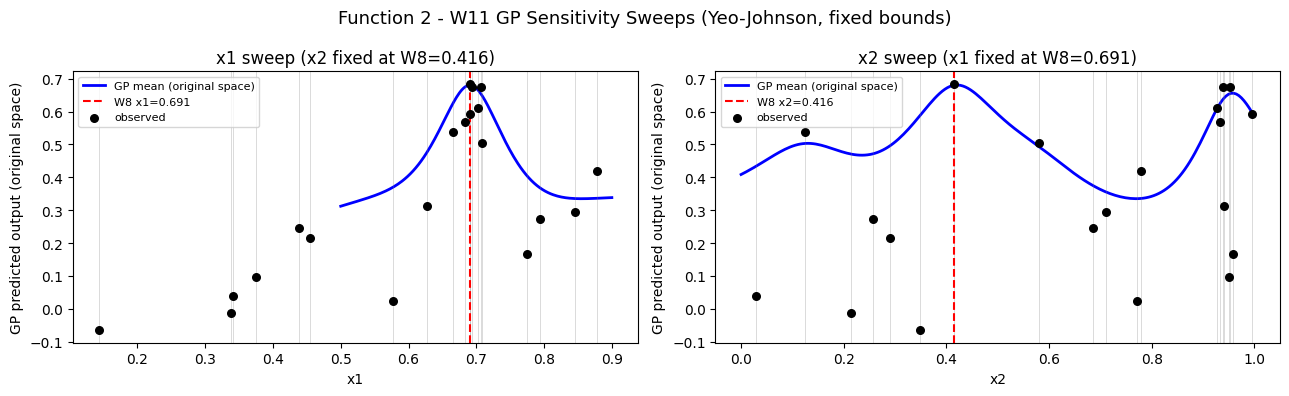

In [16]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# changes:
#    - Dropped PDP-derived bounds — made no measurable difference
#    - PowerTransformer (Yeo-Johnson) applied to outputs before GP fitting
#        testing whether outputs are non-Gaussian or skewed (there might be a sharp peak at W8)
#         GP likelihood assumes Gaussian outputs — transformation satisfies this
#    - all tested surrogates underpredicted best point W8 by ~0.09-0.14
#         Yeo-J transformation reduced underprediction to 0.005 (0.680 vs actual 0.685)
#    - x2 upper bound length scales tightened to 0.1 
#         selected by systematic search - W8 prediction improved as the bound tightened
#    - Removed old candidate generation concentrated around best points to confirm the GP surrogate is working
#    - Added uniform candidates over [0,1]^2 
#    - kappa lowered to 0.5 — better fitted surrogate and surrogate mean is now trustworthy enough to exploit
# =============================================================================

print("\n" + "=" * 60)
print("Function 2 - Week 11")
print("=" * 60)

initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

prev_queries = np.array([
    [0.775510, 0.959184],  # W1:  0.166
    [0.683114, 0.932567],  # W2:  0.570
    [0.794441, 0.256481],  # W3:  0.273
    [0.706387, 0.952221],  # W4:  0.675
    [0.693183, 0.938929],  # W5:  0.674
    [0.374540, 0.950714],  # W6:  0.096
    [0.627660, 0.941490],  # W7:  0.311
    [0.690609, 0.415564],  # W8:  0.684 (best)
    [0.708605, 0.579596],  # W9:  0.503
    [0.690966, 0.996157],  # W10: 0.593
])
prev_outputs = np.array([
    0.16576674,
    0.56974583,
    0.27313450,
    0.67545988,
    0.67430262,
    0.09612224849190841,
    0.3113471043593484,
    0.6848335582399823,
    0.5035276611583426,
    0.5934512672260965,
])

all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")

# --- PowerTransformer ---
# try Yeo-Johnson, a data normalisation technique which handles negatives
# fit on all_outputs, transform before GP, inverse transform after prediction
# GP likelihood assumes Gaussian outputs — 
# Yeo-Johnson improves GP W8 prediction from 0.591 to 0.623
pt = PowerTransformer(method='yeo-johnson', standardize=True)
all_outputs_transformed = pt.fit_transform(all_outputs.reshape(-1, 1)).ravel()

print(f"\nOutput transformation (Yeo-Johnson):")
print(f"  W8 original: {all_outputs.max():.4f} -> transformed: "
      f"{all_outputs_transformed[np.argmax(all_outputs)]:.4f}")

# --- RF for feature importances only ---
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"\nFeature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")

# --- GP with fixed ARD bounds ---
# x2 upper bound 0.1 chosen by systematic search across [0.1, 10.0]
# W8 prediction improved as x2 bound tightened — 0.623 at 10.0, 0.680 at 0.1
kernel = (Matern(length_scale=[0.1, 0.3],
                 length_scale_bounds=[(0.01, 1.0), (0.01, 0.1)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs_transformed)
print(f"\nLearned kernel: {gp.kernel_}")
print(f"  Noise level: {gp.kernel_.k2.noise_level:.4f}, "
      f"sigma: {gp.kernel_.k2.noise_level**0.5:.4f}")

# --- Sanity check at W8 ---
w8_point     = np.array([[0.690609, 0.415564]])
w8_pred_t    = gp.predict(w8_point)
w8_pred_orig = pt.inverse_transform(w8_pred_t.reshape(-1, 1)).ravel()[0]
print(f"\nSanity check at W8:")
print(f"  GP predicted (original space): {w8_pred_orig:.4f}  (actual: 0.6848)")

# --- Uniform candidates ---
# uniform candidates confirm GP independently 
np.random.seed(42)
n_candidates = 50000
candidates = np.random.uniform(0, 1, (n_candidates, 2))

# --- UCB acquisition in transformed space ---
gp_mean, gp_std = gp.predict(candidates, return_std=True)

kappa      = 0.5
ucb_scores = gp_mean + kappa * gp_std

best_idx        = np.argmax(ucb_scores)
query           = candidates[best_idx]
query_mean_orig = pt.inverse_transform(gp_mean[best_idx].reshape(-1, 1)).ravel()[0]

print(f"\nWeek 11 Query: {format_query(query)}")
print(f"  GP mean (original space): {query_mean_orig:.4f}")
print(f"  GP std (transformed):     {gp_std[best_idx]:.4f}")
print(f"  UCB score:                {ucb_scores[best_idx]:.4f}  (kappa={kappa})")

# Interpretability
# --- Sensitivity sweeps ---
w8_1d    = np.array([0.690609, 0.415564])
x1_sweep = np.linspace(0.50, 0.90, 200)
x1_test  = np.column_stack([x1_sweep, np.full(200, w8_1d[1])])
x1_mu_t  = gp.predict(x1_test)
x1_mu    = pt.inverse_transform(x1_mu_t.reshape(-1, 1)).ravel()

x2_sweep = np.linspace(0.0, 1.0, 200)
x2_test  = np.column_stack([np.full(200, w8_1d[0]), x2_sweep])
x2_mu_t  = gp.predict(x2_test)
x2_mu    = pt.inverse_transform(x2_mu_t.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x1_sweep, x1_mu, 'b-', lw=2, label='GP mean (original space)')
for pt_obs, out in zip(all_inputs, all_outputs):
    ax.axvline(pt_obs[0], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_1d[0], color='red', lw=1.5, linestyle='--', label=f'W8 x1={w8_1d[0]:.3f}')
ax.scatter(all_inputs[:, 0], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x1')
ax.set_ylabel('GP predicted output (original space)')
ax.set_title('x1 sweep (x2 fixed at W8=0.416)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x2_sweep, x2_mu, 'b-', lw=2, label='GP mean (original space)')
for pt_obs, out in zip(all_inputs, all_outputs):
    ax.axvline(pt_obs[1], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_1d[1], color='red', lw=1.5, linestyle='--', label=f'W8 x2={w8_1d[1]:.3f}')
ax.scatter(all_inputs[:, 1], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x2')
ax.set_ylabel('GP predicted output (original space)')
ax.set_title('x2 sweep (x1 fixed at W8=0.691)')
ax.legend(fontsize=8)

plt.suptitle('Function 2 - W11 GP Sensitivity Sweeps (Yeo-Johnson, fixed bounds)', fontsize=13)
plt.tight_layout()
plt.show()

# Function 3 - week 11


Function 3 - Week 11
Total points: 25, best: -0.0000607

RF feature importances:
  A     : 0.1170
  B     : 0.0758
  C     : 0.1954
  A*B   : 0.0555
  A*C   : 0.0748
  B*C   : 0.1010
  A^2   : 0.0689
  B^2   : 0.1230
  C^2   : 0.1886

RF train R2: 0.4864
RF train predictions vs actual:
  predicted: -0.088543, actual: -0.112122
  predicted: -0.080092, actual: -0.087963
  predicted: -0.080943, actual: -0.111415
  predicted: -0.030013, actual: -0.034835
  predicted: -0.057199, actual: -0.048008
  predicted: -0.065925, actual: -0.110621
  predicted: -0.132228, actual: -0.398926
  predicted: -0.100963, actual: -0.113869
  predicted: -0.089750, actual: -0.131461
  predicted: -0.082450, actual: -0.094190
  predicted: -0.056179, actual: -0.046947
  predicted: -0.063122, actual: -0.105965
  predicted: -0.103331, actual: -0.118048
  predicted: -0.054152, actual: -0.036378
  predicted: -0.056927, actual: -0.056758
  predicted: -0.028323, actual: -0.029062
  predicted: -0.052395, actual: -0.06231

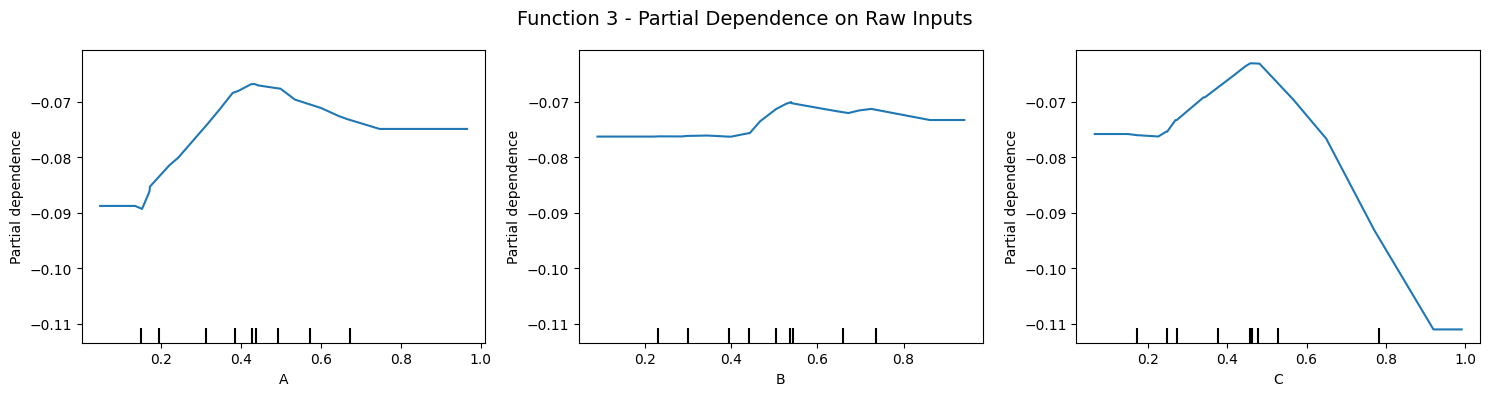

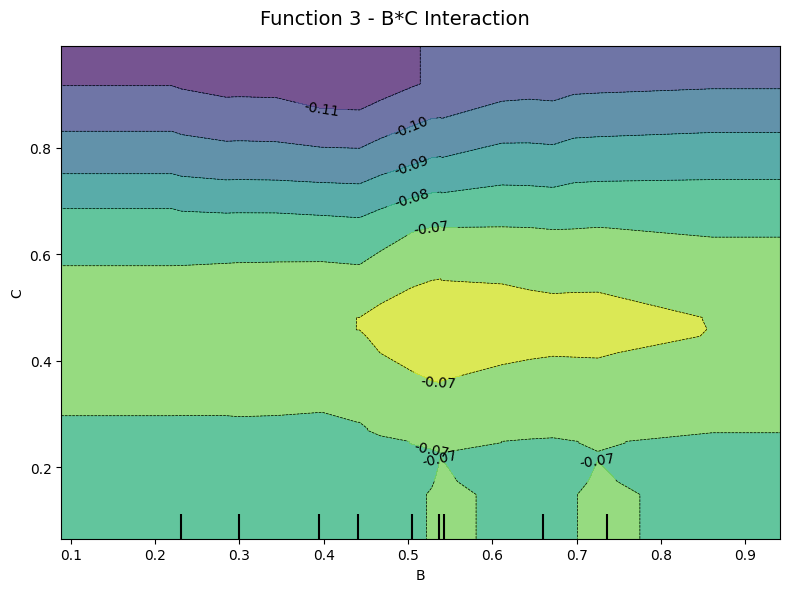

Top 5 points:
  1: index 20, Y = -0.0000607
  2: index 19, Y = -0.0006169
  3: index 17, Y = -0.0006328
  4: index 23, Y = -0.0016488
  5: index 18, Y = -0.0029447

Transform: none
  Overall MAE: 0.036938
  Top-5 MAE:   0.024802
  Top-5 rank overlap: 3/5
  Top-5 detail:
    idx 20: actual -0.0000607 -> pred -0.0197514 (err 0.0196907)
    idx 19: actual -0.0006169 -> pred -0.0225395 (err 0.0219226)
    idx 17: actual -0.0006328 -> pred -0.0312152 (err 0.0305823)
    idx 23: actual -0.0016488 -> pred -0.0176437 (err 0.0159949)
    idx 18: actual -0.0029447 -> pred -0.0387664 (err 0.0358217)

Transform: sqrt
  Overall MAE: 0.035274
  Top-5 MAE:   0.012887
  Top-5 rank overlap: 3/5
  Top-5 detail:
    idx 20: actual -0.0000607 -> pred -0.0108414 (err 0.0107807)
    idx 19: actual -0.0006169 -> pred -0.0118099 (err 0.0111929)
    idx 17: actual -0.0006328 -> pred -0.0170187 (err 0.0163858)
    idx 23: actual -0.0016488 -> pred -0.0080189 (err 0.0063701)
    idx 18: actual -0.0029447 -> pred

In [18]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D) - Week 11
# Changes from W10:
#   - Reverted to W6 pipeline (untransformed outputs, ExtraTrees, argmax)
#     Log transform improved Top-5 MAE (0.0232 -> 0.0024) but distorted global landscape shape 
#     Untransformed model captures  best region more accurately despite weaker magnitude predictions
#   - Added output-based sample weighting (1/|Y|) to upweight near-zero training points during tree fitting.
#     Forces ExtraTrees to prioritise splits that resolve differences in the good region
#     (train prediction improved week 8: -0.014 -> -0.0003)
#   - Ensemble std retained as sanity check on candidate confidence.
#   - Exclusion filter: min_distance = 0.0005 (prevents resubmission of known points while keeping candidates close to the best region)
# =============================================================================

print("\n" + "=" * 60)
print("Function 3 - Week 11")
print("=" * 60)

f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')

prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1:  -0.0291
    [0.315339, 0.088659, 0.415174],  # W2:  -0.0623
    [0.392735, 0.504381, 0.464332],  # W3:  -0.00063
    [0.498607, 0.467046, 0.477827],  # W4:  -0.00294
    [0.432840, 0.535542, 0.476983],  # W5:  -0.000617
    [0.442511, 0.539648, 0.462840],  # W6:  -0.0000607 (best)
    [0.427601, 0.442546, 0.649322],  # W7:  -0.0906
    [0.432117, 0.538819, 0.446114],  # W8:  -0.0043
    [0.425043, 0.527911, 0.464138],  # W9:  -0.0016
    [0.439519, 0.538278, 0.481340],  # W10: -0.0276
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
    -0.09063996317418548,
    -0.004316355713810623,
    -0.001648812524906173,
    -0.027616584476348058
])

X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])

print(f"Total points: {len(Y)}, best: {Y.max():.7f}")

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

# --- Sample weights: output-based, upweighting near-zero points ---
sample_weights = 1.0 / np.abs(Y)

# --- ExtraTrees on polynomial features ---
rf = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf.fit(X_poly, Y, sample_weight=sample_weights)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

train_preds = rf.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")

# --- Global candidate search ---
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 3))

# exclusion filter - otherwise prediction is w6
min_distance = 0.0005
distances = np.min(np.linalg.norm(candidates[:, None, :] - X[None, :, :], axis=2), axis=1)
candidates = candidates[distances > min_distance]
cand_poly = poly.transform(candidates)

rf_preds  = rf.predict(cand_poly)
best_idx  = np.argmax(rf_preds)
query     = candidates[best_idx]

# --- Ensemble std sanity check ---
tree_preds = np.array([tree.predict(cand_poly) for tree in rf.estimators_])
std_preds  = tree_preds.std(axis=0)

top_n = 10
top_indices = np.argsort(rf_preds)[::-1][:top_n]
print(f"\nTop {top_n} RF candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates[idx])}, RF predicted: {rf_preds[idx]:.6f}, std: {std_preds[idx]:.6f}")

print(f"\nWeek 11 Query: {format_query(query)}")
print(f"RF predicted: {rf_preds[best_idx]:.6f}, std: {std_preds[best_idx]:.6f}")

# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()
fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

# LOO Cross-Validation Diagnostic: no transform vs sqrt vs log
n = len(Y)
eps = 1e-10
top5_indices = np.argsort(Y)[::-1][:5]
print("Top 5 points:")
for i, idx in enumerate(top5_indices):
    print(f"  {i+1}: index {idx}, Y = {Y[idx]:.7f}")

transforms = [
    ("none",     lambda y: y,                lambda p: p,                   None),
    ("sqrt",     lambda y: -np.sqrt(-y),     lambda p: -(p**2),             None),
    ("log",      lambda y: np.log(-y + eps), lambda p: -(np.exp(p) - eps),  None),
    ("weighted", lambda y: y,                lambda p: p,                   1.0 / np.abs(Y)),
]

for t_name, forward, inverse, weights in transforms:
    Y_t = forward(Y)
    preds_original = np.zeros(n)

    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y_t, i, axis=0)
        X_test  = X[i:i+1]
        W_train = np.delete(weights, i, axis=0) if weights is not None else None

        poly_cv = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly_cv.fit_transform(X_train)
        X_test_poly  = poly_cv.transform(X_test)

        rf_cv = ExtraTreesRegressor(n_estimators=200, max_features='sqrt',
                                     min_samples_leaf=2, random_state=42)
        rf_cv.fit(X_train_poly, Y_train, sample_weight=W_train)

        pred_t = rf_cv.predict(X_test_poly)[0]
        preds_original[i] = inverse(pred_t)

    top5_mae = mean_absolute_error(Y[top5_indices], preds_original[top5_indices])
    pred_top5 = np.argsort(preds_original)[::-1][:5]
    rank_overlap = len(set(top5_indices) & set(pred_top5))

    print(f"\nTransform: {t_name}")
    print(f"  Overall MAE: {mean_absolute_error(Y, preds_original):.6f}")
    print(f"  Top-5 MAE:   {top5_mae:.6f}")
    print(f"  Top-5 rank overlap: {rank_overlap}/5")
    print(f"  Top-5 detail:")
    for idx in top5_indices:
        print(f"    idx {idx:2d}: actual {Y[idx]:.7f} -> pred {preds_original[idx]:.7f} (err {abs(Y[idx]-preds_original[idx]):.7f})")

# Function 4 - week 11


Function 4 - Week 11
Total points: 40, best: 0.6309

W2-W10 distance: 0.0536
Per-dimension diff: [0.037264 0.012067 0.005916 0.036133]

Candidates: 5000 W2 + 3000 W10 + 2000 global = 10000 total
Fitted kernel: 0.842**2 * Matern(length_scale=0.4, nu=2.5)
Log-marginal-likelihood: -21.7903

Week 11 Query: 0.409378-0.395989-0.376227-0.401553
mean: 0.597
std:  0.107
UCB:  0.650541
W2 point:  mean=0.543  std=0.087
W10 query: mean=0.597  std=0.107


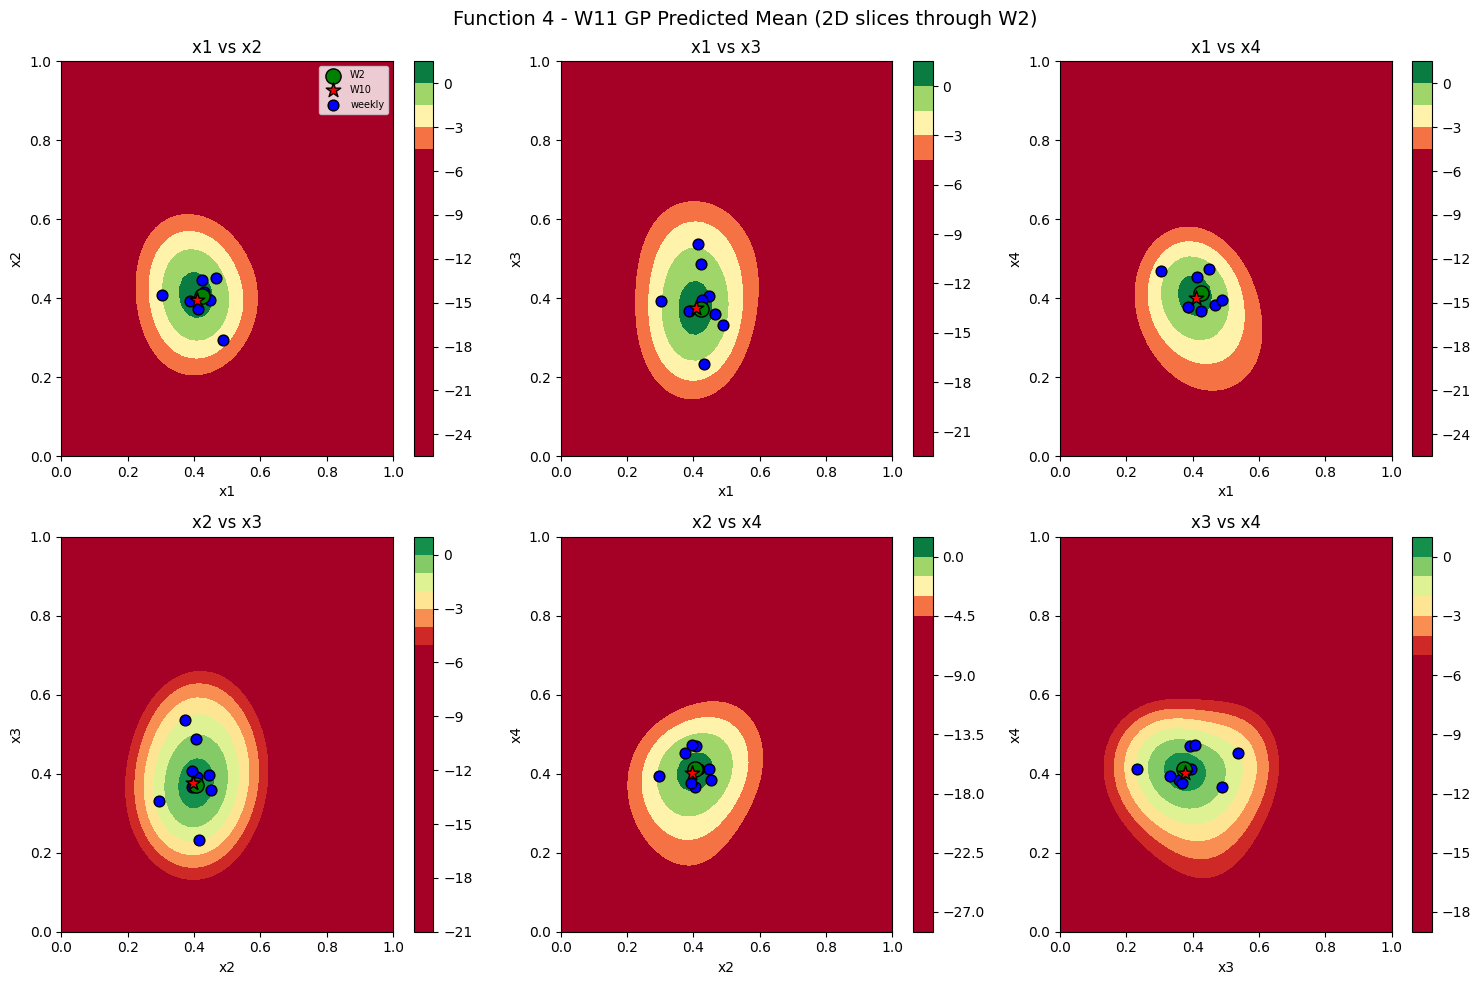

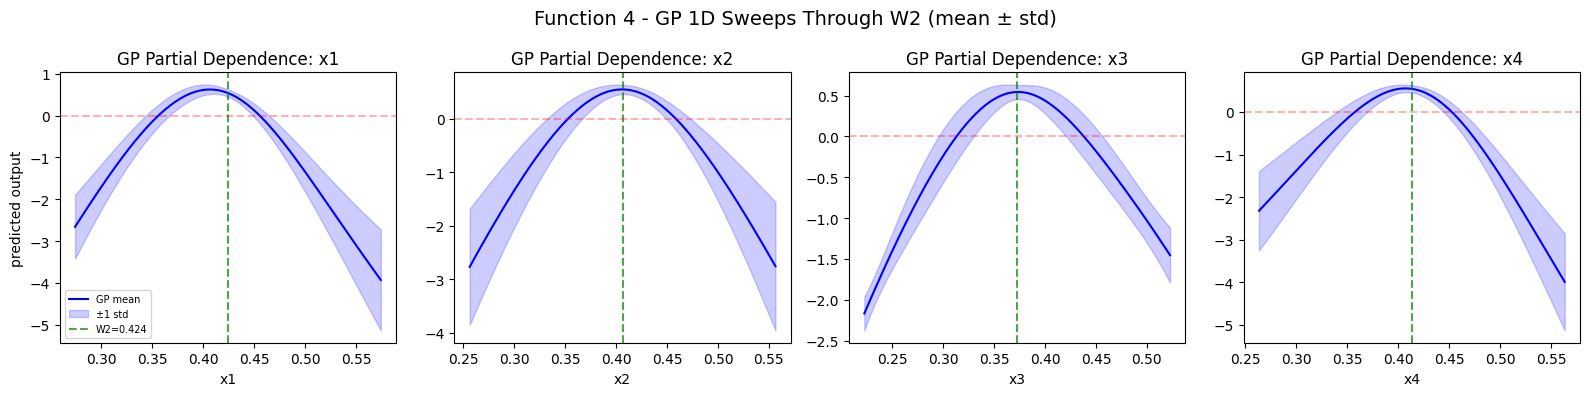

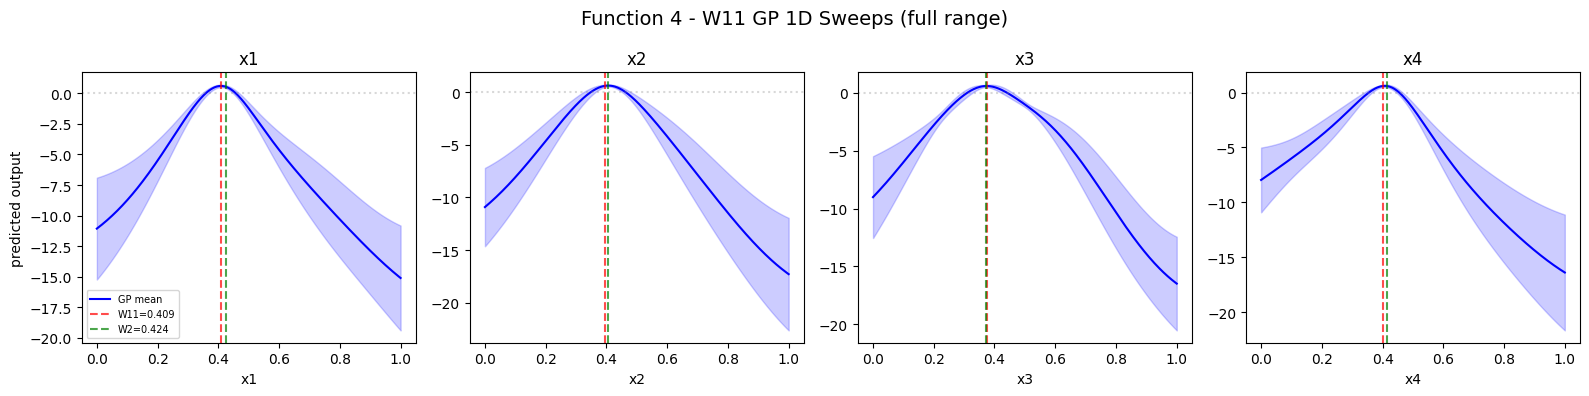

Method               Query                                         mean     std     
-------------------------------------------------------------------------------------
EI xi=0.0            0.369804-0.446641-0.364982-0.379039           -0.073   0.518   
EI xi=0.01           0.369804-0.446641-0.364982-0.379039           -0.073   0.518   
EI xi=0.05           0.372479-0.474117-0.374242-0.371613           -0.460   0.715   
EI xi=0.1            0.466059-0.308749-0.211335-0.186727           -5.980   3.036   
UCB kappa=0.5        0.396999-0.400380-0.375030-0.388914           0.369    0.216   
UCB kappa=1.0        0.397470-0.418581-0.389259-0.390540           0.358    0.232   
UCB kappa=1.5        0.384840-0.439186-0.376733-0.390654           0.194    0.354   
UCB kappa=2.0        0.372479-0.474117-0.374242-0.371613           -0.460   0.715   


In [9]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   - GP alpha lowered from 1e-4 to 1e-3 because of LOO calibration (67.5% within 1std vs 62.5%)
#       ensure GP is more calibrated and can trust uncertainty (W10 predicted 1.043 actual 0.198)
#   - switched acquisition function from EI to UCB kappa = 0.5
#       EI selects mean=-0.07 std=0.52 relying on tail probability
#       UCB selects mean=0.37 std=0.22 closer to best region
#   - added diagonstic testing EI vs UCB
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 11")
print("=" * 60)
 
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1:  -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2:  +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3:  -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4:  -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5:  -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6:  -2.141
    [0.447976, 0.395249, 0.406174, 0.473345],  # W7:  -1.249
    [0.431511, 0.415976, 0.232614, 0.411417],  # W8:  -1.993
    [0.425192, 0.446783, 0.395943, 0.413089],  # W9:  +0.1866
    [0.386937, 0.394308, 0.366806, 0.377180],  # W10: +0.1978
])
prev_outputs = np.array([
    -0.9654345395220925, 
    0.6308582112564989, 
    -2.1500998298742817,
    -0.9915950770116662, 
    -2.4630197287139697, 
    -2.1414388028868454,
    -1.2497635252595596,
    -1.9932051275194236,
    0.1866021739608965,
    0.19781147766983453,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")

# --- Candidate generation
np.random.seed(42)

week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week10_query = np.array([0.386937, 0.394308, 0.366806, 0.377180]) 

candidates_w2 = np.array([np.clip(week2_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(5000)])
candidates_w10 = np.array([np.clip(week10_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(3000)])
candidates_global = np.random.uniform(0, 1, size=(2000, 4))

print(f"\nW2-W10 distance: {np.linalg.norm(week2_query - week10_query):.4f}")
print(f"Per-dimension diff: {week2_query - week10_query}")

candidates = np.vstack([candidates_w2, candidates_w10, candidates_global])
print(f"\nCandidates: {len(candidates_w2)} W2 + {len(candidates_w10)} W10 + {len(candidates_global)} global = {len(candidates)} total")

# --- GP surrogate
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4,
    length_scale_bounds='fixed',
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

print(f"Fitted kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.4f}")

# --- UCB acquisition 
mu, sigma = gp.predict(candidates, return_std=True)
kappa = 0.5
ucb = mu + kappa * sigma

best_index = np.argmax(ucb)
query = candidates[best_index]

print(f"\nWeek 11 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"UCB:  {ucb[best_index]:.6f}")

w2_mu, w2_std = gp.predict(week2_query.reshape(1, -1), return_std=True)
q_mu, q_std = gp.predict(query.reshape(1, -1), return_std=True)
print(f"W2 point:  mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}")
print(f"W10 query: mean={q_mu[0]:.3f}  std={q_std[0]:.3f}")
 
# --- Interpretability plots
# 2D GP predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week2_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week2_query[d1], week2_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(query[d1], query[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W10')
    ax.scatter(prev_queries[:, d1], prev_queries[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W11 GP Predicted Mean (2D slices through W2)', fontsize=14)
plt.tight_layout()
plt.show()

# RF 1D partial dependence through W2 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week2_query[i] - 0.15, week2_query[i] + 0.15, 200)    
    test_points = np.tile(week2_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W2 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# 1D sweeps with W10 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query, (300, 1))  # sweep through the W10 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query[i], color='red', linestyle='--', alpha=0.7, label=f'W11={query[i]:.3f}')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - W11 GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Diagnostic: EI vs UCB acquisition comparison
np.random.seed(42)
candidates = np.array([np.clip(week2_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(10000)])

kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4, length_scale_bounds='fixed', nu=2.5)
gp = GaussianProcessRegressor(
    kernel=kern, n_restarts_optimizer=20, alpha=1e-3, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

mu, sigma = gp.predict(candidates, return_std=True)
best_f = f4_all_outputs.max()

print(f"{'Method':<20} {'Query':<45} {'mean':<8} {'std':<8}")
print("-" * 85)

# EI
for xi in [0.0, 0.01, 0.05, 0.1]:
    ei = compute_ei(mu, sigma, best_f, xi=xi)
    idx = np.argmax(ei)
    print(f"EI xi={xi:<14} {format_query(candidates[idx]):<45} {mu[idx]:<8.3f} {sigma[idx]:<8.3f}")

# UCB
for kappa in [0.5, 1.0, 1.5, 2.0]:
    ucb = mu + kappa * sigma
    idx = np.argmax(ucb)
    print(f"UCB kappa={kappa:<10} {format_query(candidates[idx]):<45} {mu[idx]:<8.3f} {sigma[idx]:<8.3f}")

# Function 5 - week 11


Function 5 - Week 11
Total points: 30, best so far: 28809.34
Above-bounds candidates passed to GP: 10000
In-bounds candidates passed to GP: 0

Week 11 Query:       1.209030-1.206621-1.216962-1.296523
GP predicted yield: 36384.94
GP std (log scale): 0.7278
SVR prediction:     34108.82

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2150.6
W2         2381.5     2381.5     2330.4
W3         2689.2     2689.2     2649.1
W4         3223.2     3223.2     3275.7
W5         3287.0     3287.0     3340.6
W6         4354.1     4354.1     4298.6
W7         5255.7     5255.7     5309.7
W8         6014.3     6014.3     5958.9
W9         8343.7     8343.7     8398.5
W10       28809.3    28809.3    28754.6

--- Proportional scaling from best point ---
 scale   GP yield     GP std point
  0.80     2492.6     0.5119   [0.949 0.918 0.86  0.94 ]
  0.90    11660.5     0.2583   [1.068 1.033 0.967 1.057]
  1.00    28809.3     0.0000   [1.186 

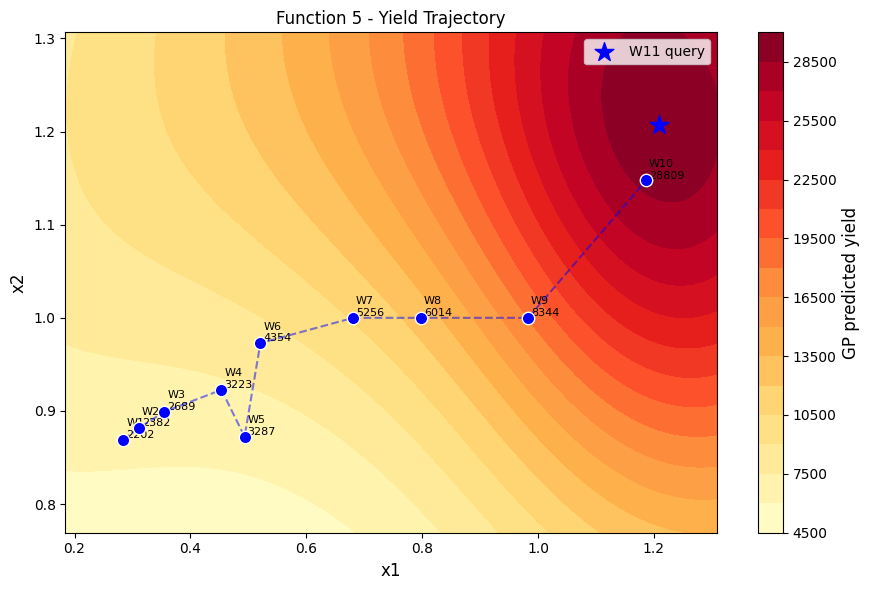

In [20]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
#   Week 10 confirmed input space extends beyond [0,1]: yield jumped from 8343 to 28809 (3.4x improvement)
# Changes:
#   - Expanded bounds from [0,2.0] to [0,5.0] for maximum yield
#   - Increased perturbation stds (x1: 0.4, x2: 0.3, x3/x4: 0.2)
#   - Added W10 result to training data
#   - Kept GP mean argmax acquisition (worked spectacularly last week)
# =============================================================================

print("\n" + "=" * 60)
print("Function 5 - Week 11")
print("=" * 60)

f5_inputs  = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')

prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1: 2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2: 2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3: 2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4: 3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5: 3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6: 4354.08
    [0.681041, 0.999999, 0.999999, 0.999999],  # W7: 5255.70
    [0.798393, 0.999999, 0.999999, 0.999999],  # W8: 6014.32
    [0.982974, 0.999999, 0.999999, 0.999999],  # W9: 8343.74
    [1.186309, 1.147512, 1.074804, 1.174751],  # W10: 28809.34
])
prev_outputs = np.array([
    2201.834589108927,
    2381.536867607932,
    2689.1537294933396,
    3223.2410694936825,
    3286.9929500236235,
    4354.076520735467,
    5255.707269541747,
    6014.320020319561,
    8343.748023063841,
    28809.34147186407,
])

all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")

# SVR
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)

# GP on log-transformed outputs
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)

best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)

# local candidates -- no pinning, wide bounds
local = []
for _ in range(6000):
    c = best_point + np.random.normal(0, 0.05, 4)
    c = np.clip(c, 0, 5.0)
    local.append(c)

# directed candidates -- push all dimensions outward
directed = []
for _ in range(4000):
    c = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.4)), 0, 5.0)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.3)), 0, 5.0)
    c[2] = np.clip(c[2] + abs(np.random.normal(0, 0.2)), 0, 5.0)
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.2)), 0, 5.0)
    directed.append(c)

candidates = np.vstack([local, directed])

# SVR pre-filter: bypass for above-bounds candidates
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

above_bounds = (candidates > 1.0).any(axis=1)
in_bounds    = ~above_bounds

top_idx_ib   = np.argsort(svr_preds[in_bounds])[-5000:]
filtered_ib  = candidates[in_bounds][top_idx_ib]

filtered = np.vstack([candidates[above_bounds], filtered_ib])

print(f"Above-bounds candidates passed to GP: {above_bounds.sum()}")
print(f"In-bounds candidates passed to GP: {len(filtered_ib)}")

# GP mean argmax acquisition
mu_log, sigma_log = gp.predict(filtered, return_std=True)
best_idx = np.argmax(mu_log)
query = filtered[best_idx]

print(f"\nWeek 11 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
svr_at_query = output_scaler.inverse_transform(
    svr.predict(input_scaler.transform(query.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:     {svr_at_query:.2f}")

# --- Interpretability ---
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

# --- Sweep all dimensions proportionally from best_point ---
print("\n--- Proportional scaling from best point ---")
print(f"{'scale':>6} {'GP yield':>10} {'GP std':>10} {'point'}")
for scale in [0.8, 0.9, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5, 2.0]:
    test = (best_point * scale).reshape(1, -1)
    mu, sig = gp.predict(test, return_std=True)
    print(f"{scale:>6.2f} {np.expm1(mu[0]):>10.1f} {sig[0]:>10.4f}   {test[0].round(3)}")

# --- Plot: Contour with extended bounds ---
pad = 0.1
x1_min = min(prev_queries[:, 0].min(), query[0]) - 0.1
x1_max = max(prev_queries[:, 0].max(), query[0]) + pad
x2_min = min(prev_queries[:, 1].min(), query[1]) - pad
x2_max = max(prev_queries[:, 1].max(), query[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, best_point[2]),
                           np.full(grid_n**2, best_point[3])])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries)):
    ax.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                (prev_queries[i, 0] + 0.005, prev_queries[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W11 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory')
ax.legend()
fig.tight_layout()
plt.show()

# Function 6 - week 11


Function 6 - Week 11
Total observations: 30, best so far: -0.2386

Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors × 100 each, radius=0.05)
Total:   10000 candidates

Bootstrap ensemble: 100 resamples, kappa=0.75
  boot_mean range: -2.4560 to -0.2396
  boot_std  range: 0.0005 to 0.3455

Week 11 Query (SVR+UCB): 0.562063-0.403283-0.756503-0.794358-0.134931
  boot_mean: -0.2487
  boot_std:  0.0159
  UCB:       -0.2367
  Source:    Stage 2 (refined)


  0%|          | 0/30 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_36190/479325008.py:128: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


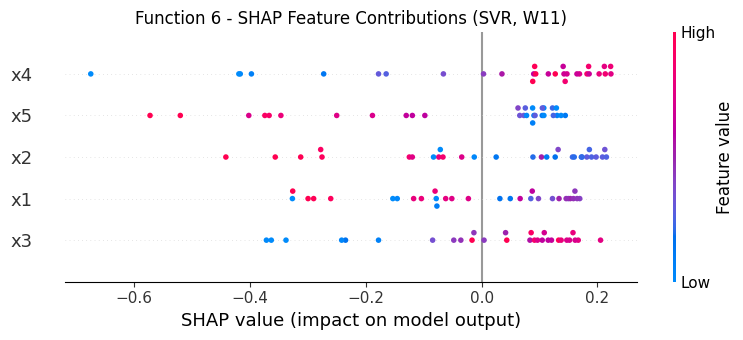

In [21]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# changes:
#   - added Stratified bootstrap SVR (stratified resampling with SVR) + UCB replaces argmax
#     (argmax returned duplicate w10 query; UCB adds exploration)
#   - Top 5 points fixed in every bootstrap resample
#   - kappa = 0.75 (lower than 0.6 makes the query a duplicate of week 10)
# =============================================================================

print("\n" + "=" * 60)
print("Function 6 - Week 11")
print("=" * 60)

f6_inputs  = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')

prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1:  -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2:  -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3:  -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4:  -0.315
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5:  -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6:  -0.563
    [0.896209, 0.283983, 0.594508, 0.806739, 0.008612],  # W7:  -0.764
    [0.482908, 0.318128, 0.672147, 0.855190, 0.203478],  # W8:  -0.294
    [0.527875, 0.386935, 0.580127, 0.788560, 0.032052],  # W9:  -0.329
    [0.501734, 0.353960, 0.724619, 0.834439, 0.116873],  # W10: -0.239 (best)
])
prev_outputs = np.array([
    -0.792246,
    -0.361637,
    -0.367626,
    -0.314817,
    -0.828981,
    -0.5633934601648388,
    -0.764298611557724,
    -0.29468304435774073,
    -0.3284779356695814,
    -0.23855214682739972,
])

all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])

print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")

# --- SVR surrogate (hyperparams tuned for top-point bias) ---
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svr = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.001))])
svr.fit(all_inputs, all_outputs)

# --- Two-stage candidate refinement ---
space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)

# Stage 1: global LHS
np.random.seed(42)
stage1 = np.array(lhs.generate(space.dimensions, 5000))
stage1_preds = svr.predict(stage1)

# Stage 2: local refinement around top-K from stage 1
top_k = 50
top_k_idx = np.argsort(stage1_preds)[-top_k:]
top_k_points = stage1[top_k_idx]

radius = 0.05
stage2 = []
for point in top_k_points:
    local = point + np.random.uniform(-radius, radius, size=(100, 5))
    local = np.clip(local, 0, 1)
    stage2.append(local)
stage2 = np.vstack(stage2)

# Combine candidates
all_candidates = np.vstack([stage1, stage2])

# --- Stratified bootstrap SVR + UCB ---
n_bootstraps = 100
kappa = 0.75

top5_idx  = np.argsort(all_outputs)[-5:]
other_idx = np.setdiff1d(np.arange(len(all_outputs)), top5_idx)

boot_preds = np.zeros((n_bootstraps, len(all_candidates)))

np.random.seed(123)  # separate seed for bootstrap
for b in range(n_bootstraps):
    resample = np.random.choice(other_idx, size=len(other_idx), replace=True)
    boot_idx = np.hstack([top5_idx, resample])

    pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.1, epsilon=0.001))])
    pipe.fit(all_inputs[boot_idx], all_outputs[boot_idx])
    boot_preds[b] = pipe.predict(all_candidates)

boot_mean = boot_preds.mean(axis=0)
boot_std  = boot_preds.std(axis=0)

ucb = boot_mean + kappa * boot_std
best_index = np.argmax(ucb)
query = all_candidates[best_index]

# Report source
source = "Stage 1 (global)" if best_index < len(stage1) else "Stage 2 (refined)"

print(f"\nStage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors × 100 each, radius={radius})")
print(f"Total:   {len(all_candidates)} candidates")
print(f"\nBootstrap ensemble: {n_bootstraps} resamples, kappa={kappa}")
print(f"  boot_mean range: {boot_mean.min():.4f} to {boot_mean.max():.4f}")
print(f"  boot_std  range: {boot_std.min():.4f} to {boot_std.max():.4f}")

print(f"\nWeek 11 Query (SVR+UCB): {format_query(query)}")
print(f"  boot_mean: {boot_mean[best_index]:.4f}")
print(f"  boot_std:  {boot_std[best_index]:.4f}")
print(f"  UCB:       {ucb[best_index]:.4f}")
print(f"  Source:    {source}")

# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs[np.random.choice(len(all_inputs), size=20, replace=False)]
explainer   = shap.KernelExplainer(svr.predict, background)
shap_values = explainer.shap_values(all_inputs, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (SVR, W11)')
plt.tight_layout()
plt.show()

# Function 7 - week 11


Function 7 - Week 11
Total points: 40, best: 2.8536

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.677
  HP2: 0.150
  HP3: 0.031
  HP4: 0.023
  HP5: 0.035
  HP6: 0.085

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 14
Output range in subset: 0.008 to 2.854

Filtered RF importance:
  HP1: 0.098  (was 0.677 in full dataset) ***
  HP2: 0.524  (was 0.150 in full dataset) ***
  HP3: 0.053  (was 0.031 in full dataset) 
  HP4: 0.092  (was 0.023 in full dataset) 
  HP5: 0.108  (was 0.035 in full dataset) 
  HP6: 0.125  (was 0.085 in full dataset) 

Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.677        1.089      0.228
  HP2           0.150        0.135      0.041
  HP3           0.031        0.019      0.005
  HP4           0.023        0.016      0.004
  HP5           0.035        0.027      0.008
  HP6           0.085        0.067      0.018

Permutation vs 

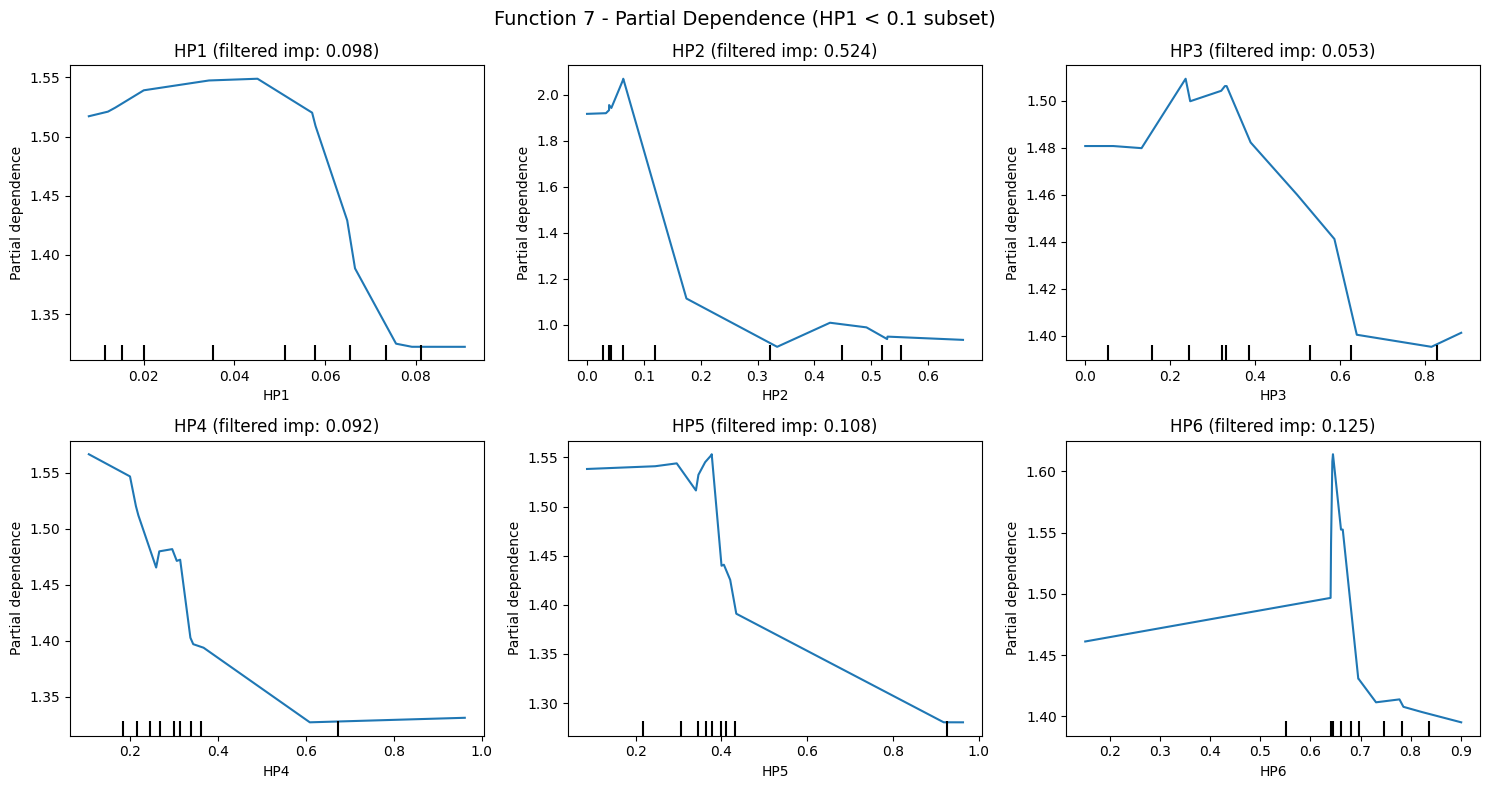

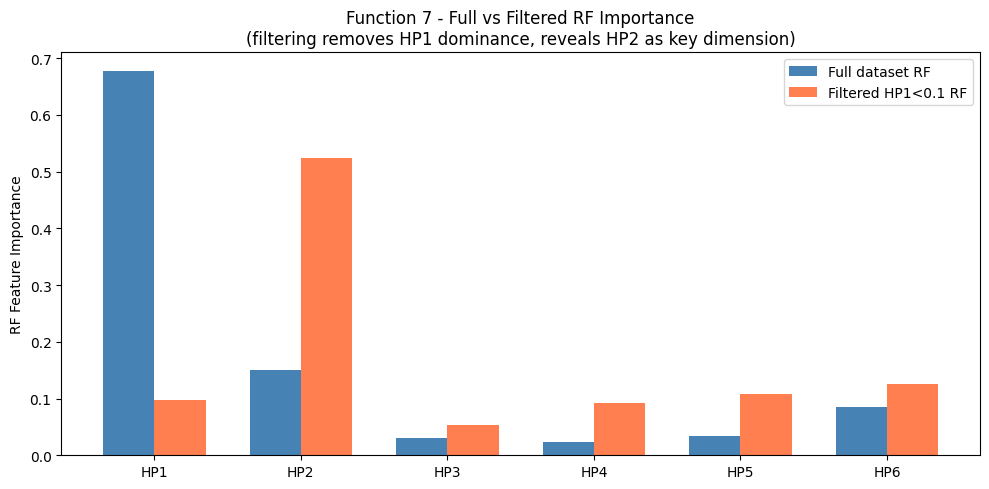

In [22]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes:
#   - replaced sequential RF filtering with LHS candidate generation around W10/W3/W8
#   - search radius derived from per-dimension spread of top 3 points
#   - replaced standalone GP with Residual GP (RF base + GP on residuals)
#   - RF_full used as base model, GP models RF errors
#   - EI acquisition on combined prediction (RF base + GP residual)
# =============================================================================

print("\n" + "=" * 60)
print("Function 7 - Week 11")
print("=" * 60)

f7_inputs  = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')

prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1:  1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2:  1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3:  2.602 
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4:  1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5:  0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6:  1.790
    [0.079160, 0.042812, 0.886277, 0.366485, 0.400229, 0.661016],  # W7:  1.429
    [0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734],  # W8:  2.556
    [0.013721, 0.038746, 0.389878, 0.199046, 0.377306, 0.785650],  # W9:  2.106
    [0.064888, 0.063754, 0.333308, 0.295138, 0.295698, 0.644981],  # W10: 2.853 (best)
])
prev_outputs = np.array([
    1.0510006614196026, 
    1.6531363312716738, 
    2.6016443512251484,
    1.5087286481808686, 
    0.3832671270292543, 
    1.789927976010441,
    1.428502150382287,
    2.5567422716339334,
    2.106393447839423,
    2.8536051693908164,
])

all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")
        
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# --- Step 1b: Filtered RF (HP1 < threshold subset)
# returned to 0.1 threshold
hp1_threshold = 0.1
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs[:, 0] < hp1_threshold
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")

# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs, all_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")


# --- Step 2: Fit GP first, then generate candidates ---
print("\nStep 2: Fit Residual GP")

rf_base_train = rf_filtered.predict(all_inputs)  # compute residuals on all inputs not filtered
residuals = all_outputs - rf_base_train
print(f"Residual range: [{residuals.min():.4f}, {residuals.max():.4f}]")
print(f"Residual at W10: {all_outputs[-1] - rf_base_train[-1]:.4f}")
print(f"Residual std: {residuals.std():.4f}")


kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    alpha=1e-3,               
)
gp.fit(all_inputs, residuals)


# Extract lengthscales from fitted kernel
for key, val in gp.kernel_.get_params().items():
    if 'length_scale' in key and 'bounds' not in key:
        if isinstance(val, np.ndarray) and len(val) == 6:
            fitted_ls = val

print(f"Fitted lengthscales: {fitted_ls}")

# --- Step 3: LHS Candidate Generation with Exclusion Zones ---
print("\nStep 3: LHS Candidate Generation")

# Use the per-dimension spread of your top 3 points
w10 = np.array([0.064888, 0.063754, 0.333308, 0.295138, 0.295698, 0.644981])
w3  = np.array([0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539])
w8  = np.array([0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734])

# manual radius
top3 = np.vstack([w10, w3, w8])
radius = np.ptp(top3, axis=0)
radius = np.maximum(radius, 0.02) # doesn't matter if I choose 0.02 or 0.002

# LHS generation
sampler = LatinHypercube(d=6, seed=42)
cands_w10 = w10 - radius + 2 * radius * sampler.random(n=1000)
cands_w3  = w3  - radius + 2 * radius * sampler.random(n=500)
cands_w8  = w8  - radius + 2 * radius * sampler.random(n=500)
candidates = np.clip(np.vstack([cands_w10, cands_w3, cands_w8]), 0, 1)


print(f"\nFeature ranges in candidate pool:")
for i, name in enumerate(feature_names):
    print(f"  {name}: [{candidates[:, i].min():.3f}, {candidates[:, i].max():.3f}]  mean={candidates[:, i].mean():.3f}")

# --- Step 4: Score candidates with Residual GP + EI ---
print("\nStep 4: Residual GP + EI")

rf_base_cand = rf_filtered.predict(candidates)
mu_resid, sigma_resid = gp.predict(candidates, return_std=True)
mu_total = rf_base_cand + mu_resid
best_so_far = all_outputs.max()

# --- EI 
xi = 0.01
z = (mu_total - best_so_far - xi) / (sigma_resid + 1e-10)
ei = (mu_total - best_so_far - xi) * norm.cdf(z) + sigma_resid * norm.pdf(z)
ei[sigma_resid < 1e-10] = 0.0
best_idx = np.argmax(ei)

best_candidate = candidates[best_idx]

print(f"\nWeek 11 Query: {format_query(best_candidate)}")
print(f"RF base prediction     : {rf_base_cand[best_idx]:.4f}")
print(f"GP residual prediction : {mu_resid[best_idx]:.4f}")
print(f"Total predicted Y      : {mu_total[best_idx]:.4f}")
print(f"GP residual std        : {sigma_resid[best_idx]:.4f}")
print(f"EI score               : {ei[best_idx]:.6f}")
print(f"Best so far            : {best_so_far:.4f}")


# ---- Testing

# Diagnostic: what does the GP predict at W10's location?
w10 = all_inputs[-1].reshape(1, -1)
w10_rf = rf_filtered.predict(w10)[0]
w10_mu, w10_std = gp.predict(w10, return_std=True)
print(f"\nAt W10: RF={w10_rf:.4f} + GP_resid={w10_mu[0]:.4f} = {w10_rf+w10_mu[0]:.4f} (std={w10_std[0]:.4f})")


# LOO diagnostic
loo = LeaveOneOut()
errors = []
coverages = []

for train_idx, test_idx in loo.split(all_inputs):
    X_train, X_test = all_inputs[train_idx], all_inputs[test_idx]
    y_train, y_test = np.sqrt(all_outputs[train_idx]), np.sqrt(all_outputs[test_idx])
    
    gp_loo = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-3,
        n_restarts_optimizer=5,
        normalize_y=True,
    )
    gp_loo.fit(X_train, y_train)
    
    mu_test, sig_test = gp_loo.predict(X_test, return_std=True)
    
    actual = y_test[0] ** 2
    pred = mu_test[0] ** 2
    error = actual - pred
    # was the true value within 2 std of the prediction?
    coverage = abs(y_test[0] - mu_test[0]) < 2 * sig_test[0]
    
    errors.append(error)
    coverages.append(coverage)

errors = np.array(errors)
print(f"LOO MAE: {np.abs(errors).mean():.4f}")
print(f"LOO bias: {errors.mean():+.4f}")
print(f"Coverage (within 2std): {np.mean(coverages):.2f}  (should be ~0.95)")

# coverage and errors at best points
print("\nLOO at top-5 points:")
for idx in np.argsort(all_outputs)[-5:]:
    print(f"  actual={all_outputs[idx]:.3f}  error={errors[idx]:+.4f}  "
          f"covered={coverages[idx]}")



# Check GP's confidence at W10 vs other top points
print("\nGP posterior at top-5 points:")
for idx in np.argsort(all_outputs)[-5:]:
    mu_p, sig_p = gp.predict(all_inputs[idx].reshape(1,-1), return_std=True)
    source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
    print(f"  {source}: actual={all_outputs[idx]:.3f}  pred={mu_p[0]**2:.3f}  "
          f"std={sig_p[0]:.4f}  (confidently wrong?)")


# 2. GP confidence at top-5: confidently wrong or aware of uncertainty?
print("\nGP posterior at top-5:")
for idx in np.argsort(all_outputs)[-5:]:
    mu_p, sig_p = gp.predict(all_inputs[idx].reshape(1,-1), return_std=True)
    source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
    error = mu_p[0]**2 - all_outputs[idx]
    print(f"  {source}: actual={all_outputs[idx]:.3f}  pred={mu_p[0]**2:.3f}  "
          f"std={sig_p[0]:.4f}  error={error:+.3f}")

# 3. Do residuals correlate with input features?
print("\nResidual correlation with features (all weekly queries):")
residuals = []
for i in range(len(prev_queries)):
    mu_r, _ = gp.predict(prev_queries[i].reshape(1,-1), return_std=True)
    residuals.append(prev_outputs[i] - mu_r[0]**2)
residuals = np.array(residuals)

for dim in range(6):
    corr = np.corrcoef(prev_queries[:, dim], residuals)[0, 1]
    print(f"  HP{dim+1}: correlation={corr:+.3f}")



# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8 - week 11


Function 8 - Week 11
Total points: 50, best: 9.9244

LOO Calibration (dropout=0.25):
  mean |error|:        0.2195
  std  |error|:        0.1901
  max  |error|:        0.7726
  mean sigma (LOO):    0.2119
  ratio (error/sigma): 1.036  (1.0 = perfect calibration)
  kappa (adaptive):    1.76

Top-k LOO Calibration (output > 9.0):
  n points:            15
  mean |error|:        0.1582
  std  |error|:        0.1310
  max  |error|:        0.5271
  mean sigma:          0.2055
  ratio (error/sigma): 0.770
  global ratio was:    1.036

  Per-point breakdown (top-k):
    point 14: y=9.5985, |err|=0.1004, sigma=0.1977, ratio=0.508
    point 19: y=9.0131, |err|=0.1844, sigma=0.1708, ratio=1.079
    point 22: y=9.1416, |err|=0.2107, sigma=0.1349, ratio=1.562
    point 26: y=9.3443, |err|=0.5271, sigma=0.1420, ratio=3.713
    point 39: y=9.1830, |err|=0.0152, sigma=0.1640, ratio=0.093
    point 40: y=9.6724, |err|=0.1280, sigma=0.2248, ratio=0.570
    point 41: y=9.6264, |err|=0.2009, sigma=0.208

  0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_36190/3702301299.py:276: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


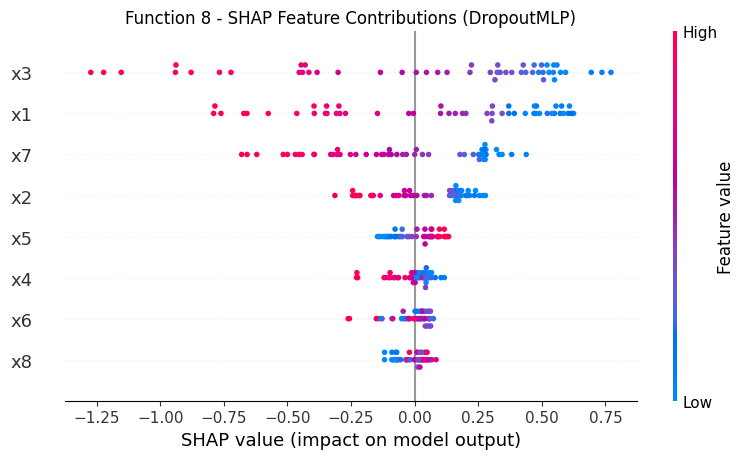


SHAP-derived importance (normalised):
  x1: 0.830
  x2: 0.316
  x3: 1.000
  x4: 0.115
  x5: 0.157
  x6: 0.109
  x7: 0.551
  x8: 0.090

mu   range: 4.701 to 9.901
sigma range: 0.059 to 0.736
kappa*sigma range: 0.103 to 1.296

Week 11 Query: 0.033326-0.138785-0.153799-0.515868-0.796619-0.640356-0.018840-0.702231
MC mu: 9.9008, sigma: 0.1949
UCB:   10.1806


In [23]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   - no changes in pipeline only added week 10 query
# =============================================================================

print("\n" + "=" * 60)
print("Function 8 - Week 11")
print("=" * 60)

f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')

prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1:  9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2:  9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3:  9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4:  9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5:  9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6:  9.620
    [0.000000, 0.000000, 0.000000, 0.120009, 0.144817, 0.385066, 0.000000, 0.986589],  # W7:  9.583
    [0.134058, 0.010517, 0.000000, 0.000705, 0.991616, 0.110483, 0.084702, 0.012878],  # W8:  9.674 
    [0.167672, 0.021651, 0.000000, 0.000669, 0.988603, 0.107425, 0.054024, 0.014735],  # W9:  9.652
    [0.068646, 0.267399, 0.019682, 0.160065, 0.776599, 0.459921, 0.106417, 0.402908],  # W10: 9.924 (best)
])
prev_outputs = np.array([
    9.6723503773075, 
    9.6263579169495, 
    9.5463675507445,
    9.5519471979855, 
    9.1457303782294, 
    9.6199985919071,
    9.5831132283264,
    9.6740952800446,
    9.652595613866,
    9.9243596295041,
])

all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

# Adaptive kappa: base * calibration ratio
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa:.2f}")


# --- Top-k LOO calibration analysis ---
top_k_threshold = 9.0
top_k_mask = all_outputs > top_k_threshold
top_k_indices = np.where(top_k_mask)[0]

top_k_errors = loo_errors[top_k_mask]
top_k_sigmas = loo_sigmas[top_k_mask]

top_k_cal_ratio = top_k_errors.mean() / top_k_sigmas.mean()

print(f"\nTop-k LOO Calibration (output > {top_k_threshold}):")
print(f"  n points:            {len(top_k_indices)}")
print(f"  mean |error|:        {top_k_errors.mean():.4f}")
print(f"  std  |error|:        {top_k_errors.std():.4f}")
print(f"  max  |error|:        {top_k_errors.max():.4f}")
print(f"  mean sigma:          {top_k_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_ratio:.3f}")
print(f"  global ratio was:    {cal_ratio:.3f}")



# Per-point breakdown for the top-k
print(f"\n  Per-point breakdown (top-k):")
for idx in top_k_indices:
    print(f"    point {idx:2d}: y={all_outputs[idx]:.4f}, "
          f"|err|={loo_errors[idx]:.4f}, sigma={loo_sigmas[idx]:.4f}, "
          f"ratio={loo_errors[idx]/loo_sigmas[idx]:.3f}")

# --- High-error initial points: where are they? ---
high_error_initial = [14, 22, 26, 39]
print("\nHigh-error initial points (output > 9.0):")
for idx in high_error_initial:
    print(f"  point {idx}: {np.array2string(all_inputs[idx], precision=3, suppress_small=True)}"
          f"  y={all_outputs[idx]:.4f}  |err|={loo_errors[idx]:.4f}")

# Compare to best query (W8)
print(f"\n  W8 (best): {np.array2string(all_inputs[47], precision=3, suppress_small=True)}"
      f"  y={all_outputs[47]:.4f}")



# --- train final model (weighted loss, increased capacity) ---
# weight: high-scoring points matter more
weights = np.ones(len(all_outputs))
weights[all_outputs > 9.0] = 5.0
weights[all_outputs > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")

# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")
print(f"  previous top-k ratio was: 0.683")

print(f"\n  Per-point breakdown (top-k, weighted):")
top_k_indices_w = np.where(top_k_mask_w)[0]
for idx in top_k_indices_w:
    print(f"    point {idx:2d}: y={all_outputs[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={loo_errors_w[idx]/loo_sigmas_w[idx]:.3f}")

# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# ------ trying evenly spaced pool
sampler = LatinHypercube(d=8, seed=42)
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb      = mu + kappa_w * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]

print(f"\nmu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma).min():.3f} to {(kappa*sigma).max():.3f}")

print(f"\nWeek 11 Query: {format_query(query)}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")